# Library

In [18]:
import pandas as pd
from supabase import create_client, Client
import os
from dotenv import load_dotenv
import plotly.express as px

# Data Loader from Supabase

In [19]:
load_dotenv()
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

In [20]:
# response = supabase.table("customer_churn_raw").select("*").range(0, 7043).execute()

all_data = []
batch_size = 1000
offset = 0

while True:
    response = supabase.table("customer_churn_raw").select("*").range(offset, offset+batch_size-1).execute()
    if not response.data:
        break
    all_data.extend(response.data)
    offset += batch_size


In [21]:
df = pd.DataFrame(all_data)
df.shape

(7043, 21)

In [22]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [23]:
response = supabase.table("customer_churn_raw").select("*").limit(5).execute()
print(response.data)   # cek isi langsung


[{'customerID': '7590-VHVEG', 'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 1, 'PhoneService': 'No', 'MultipleLines': 'No phone service', 'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'No', 'StreamingMovies': 'No', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check', 'MonthlyCharges': 29.85, 'TotalCharges': '29.85', 'Churn': 'No'}, {'customerID': '5575-GNVDE', 'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 34, 'PhoneService': 'Yes', 'MultipleLines': 'No', 'InternetService': 'DSL', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'No', 'DeviceProtection': 'Yes', 'TechSupport': 'No', 'StreamingTV': 'No', 'StreamingMovies': 'No', 'Contract': 'One year', 'PaperlessBilling': 'No', 'PaymentMethod': 'Mailed check', 'MonthlyCharges': 56.95, 'TotalCharges': '1889.5', 'Churn': 'No'}, {'customerID'

# Data Profailing

Dataset Telco Customer Churn berisi informasi pelanggan perusahaan telekomunikasi yang digunakan untuk menganalisis perilaku pelanggan dan memprediksi kemungkinan pelanggan berhenti menggunakan layanan (customer churn).

Setiap baris merepresentasikan satu pelanggan, sedangkan setiap kolom merepresentasikan atribut pelanggan seperti informasi demografi, layanan yang digunakan, kontrak, pembayaran, hingga status churn pelanggan.
| No. | Nama Variabel | Deskripsi | Tipe Data |
|---|---|---|---|
| 1 | customerID | ID unik untuk setiap pelanggan | Object / String |
| 2 | gender | Jenis kelamin pelanggan (Male/Female) | Categorical |
| 3 | SeniorCitizen | Status pelanggan lansia (0 = Tidak, 1 = Ya) | Integer / Binary |
| 4 | Partner | Menunjukkan apakah pelanggan memiliki pasangan | Categorical |
| 5 | Dependents | Menunjukkan apakah pelanggan memiliki tanggungan | Categorical |
| 6 | tenure | Lama pelanggan berlangganan dalam satuan bulan | Integer |
| 7 | PhoneService | Status penggunaan layanan telepon | Categorical |
| 8 | MultipleLines | Menunjukkan apakah pelanggan memiliki lebih dari satu jalur telepon | Categorical |
| 9 | InternetService | Jenis layanan internet yang digunakan pelanggan | Categorical |
| 10 | OnlineSecurity | Status layanan keamanan online | Categorical |
| 11 | OnlineBackup | Status layanan backup online | Categorical |
| 12 | DeviceProtection | Status layanan perlindungan perangkat | Categorical |
| 13 | TechSupport | Status layanan dukungan teknis | Categorical |
| 14 | StreamingTV | Status layanan streaming TV | Categorical |
| 15 | StreamingMovies | Status layanan streaming film | Categorical |
| 16 | Contract | Jenis kontrak pelanggan | Categorical |
| 17 | PaperlessBilling | Status penggunaan tagihan tanpa kertas | Categorical |
| 18 | PaymentMethod | Metode pembayaran pelanggan | Categorical |
| 19 | MonthlyCharges | Total biaya tagihan pelanggan per bulan | Float |
| 20 | TotalCharges | Total keseluruhan biaya yang telah dibayarkan pelanggan | Float |
| 21 | Churn | Status pelanggan berhenti berlangganan (Yes/No) | Binary / Categorical |

In [24]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Preprocessing

## Cek Missing Value

In [27]:
# tidak ada missing value pada dataset ini

## Handling Missing Value

In [28]:
# tidak ada missing value pada dataset ini

## Standarisasi/Normasisasi

Dari hasil analisis tipe data pada dataset Telco Customer Churn, variabel yang bertipe data kategorikal adalah:

- `gender`
- `Partner`
- `Dependents`
- `PhoneService`
- `MultipleLines`
- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `StreamingTV`
- `StreamingMovies`
- `Contract`
- `PaperlessBilling`
- `PaymentMethod`
- `Churn`

Variabel-variabel tersebut masih berbentuk kategori atau label teks sehingga perlu dilakukan proses encoding sebelum digunakan dalam pemodelan machine learning.

## Outliers

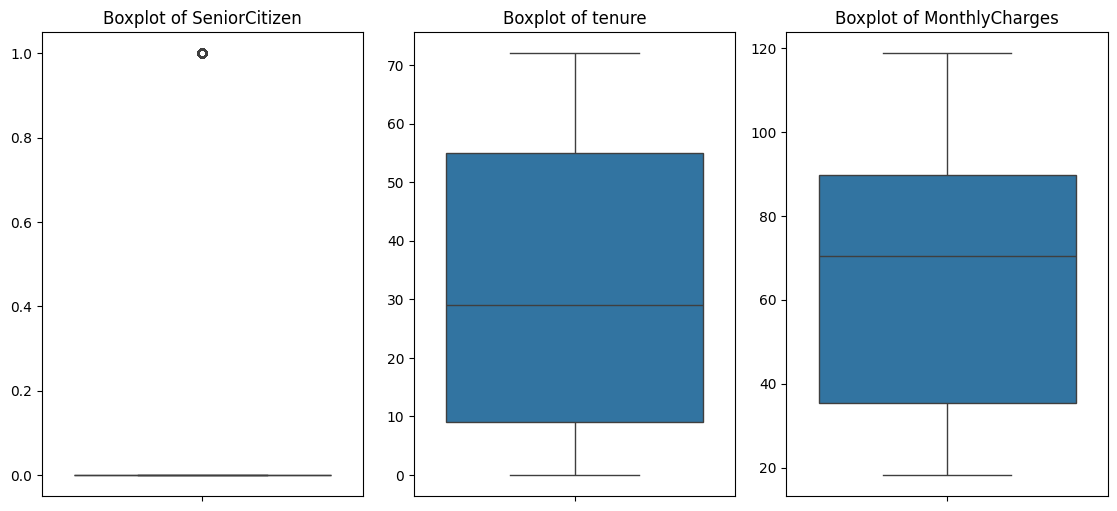

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns

# Membuat visualisasi boxplot untuk setiap kolom numerik
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 4, i + 1) # Sesuaikan grid sesuai jumlah kolom
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

## Imbalace

In [30]:
# Hitung distribusi target
target_counts = df['Churn'].value_counts().reset_index()
target_counts.columns = ['Churn', 'Count']

# Visualisasi interaktif
fig = px.bar(
    target_counts,
    x='Churn',
    y='Count',
    color='Churn',
    text='Count',
    title='Distribusi Target (Churn)',
    labels={'Churn':'Status Churn', 'Count':'Jumlah'}
)

fig.update_traces(textposition='outside')
fig.show()
